# Deep Learning Training & Evaluation

Analyzes LSTM, 1D CNN, and Transformer results from cell-based LOOCV
with Optuna hyperparameter tuning. Compares DL performance against classical baselines.

In [1]:
import sys
import os
from pathlib import Path

_cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "config" / "default.yaml").exists():
        PROJECT_ROOT = _p
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Cannot find project root (config/default.yaml). "
        f"Searched from {_cwd} up to {_cwd.parents[-1]}"
    )
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import mlflow

sns.set_theme(style="whitegrid", context="notebook")

with open("config/default.yaml") as f:
    config = yaml.safe_load(f)
print(f"Project root: {PROJECT_ROOT}")

/opt/anaconda3/envs/soh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/malakmekyassi/Documents/GitHub/soh_estimation


## 1. Load Results

In [2]:
with open("experiments/classical_results_nasa.yaml") as f:
    classical_results = yaml.safe_load(f)

with open("experiments/dl_results_nasa.yaml") as f:
    dl_results = yaml.safe_load(f)

all_results = {**classical_results, **dl_results}
dl_models = ["lstm", "cnn", "transformer"]
print("Models:", list(all_results.keys()))
for name, m in all_results.items():
    if not isinstance(m, dict) or "rmse_mean" not in m:
        continue
    print(f"  {name.upper():>12s}: RMSE={m['rmse_mean']:.6f} +/- {m['rmse_std']:.6f}, R2={m['r2_mean']:.4f}")

Models: ['_meta', 'gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']
           GPR: RMSE=0.028286 +/- 0.016620, R2=0.8858
         NAIVE: RMSE=0.107574 +/- 0.024956, R2=-0.4132
            RF: RMSE=0.029348 +/- 0.018821, R2=0.8790
           SVR: RMSE=0.025303 +/- 0.019143, R2=0.9010
           CNN: RMSE=0.058668 +/- 0.019108, R2=0.0696
          LSTM: RMSE=0.039709 +/- 0.013218, R2=0.6299
   TRANSFORMER: RMSE=0.047688 +/- 0.013785, R2=0.3562


## 2. Fetch Fold-level Metrics from MLflow

In [3]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("soh_benchmark")

client = mlflow.MlflowClient()
experiment = client.get_experiment_by_name("soh_benchmark")

# Only the NASA dataset runs (tagged during training); the legacy
# pre-remediation runs have no dataset tag and are excluded.
all_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.dataset = 'nasa'",
    order_by=["start_time asc"],
)

run_records = []
for run in all_runs:
    params = run.data.params
    tags = run.data.tags
    metrics = run.data.metrics
    model = params.get("model", tags.get("model", "unknown"))
    fold = params.get("fold", tags.get("fold", None))
    seed = params.get("seed", tags.get("seed", None))
    if fold is not None and "rmse" in metrics:
        run_records.append({
            "model": model,
            "fold": int(fold),
            "seed": int(seed) if seed else None,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "maxae": metrics["maxae"],
            "r2": metrics["r2"],
        })

runs_df = pd.DataFrame(run_records)
print(f"Total runs: {len(runs_df)}")
if len(runs_df) > 0:
    print(runs_df.groupby(["model", "fold"])["rmse"].agg(["mean", "std"]).round(6))

Total runs: 52
                      mean       std
model       fold                    
cnn         0     0.045598  0.016103
            1     0.091416  0.099286
            2     0.045389  0.012415
            3     0.052268  0.008923
gpr         0     0.016512       NaN
            1     0.053963       NaN
            2     0.011079       NaN
            3     0.031591       NaN
lstm        0     0.025609  0.006567
            1     0.051680  0.017873
            2     0.027462  0.016637
            3     0.054086  0.016110
naive       0     0.099712       NaN
            1     0.149943       NaN
            2     0.094730       NaN
            3     0.085911       NaN
rf          0     0.018639       NaN
            1     0.061941       NaN
            2     0.018887       NaN
            3     0.017924       NaN
svr         0     0.012892       NaN
            1     0.057331       NaN
            2     0.008652       NaN
            3     0.022338       NaN
transformer 0     0.031

## 3. Fold-wise RMSE: DL Models

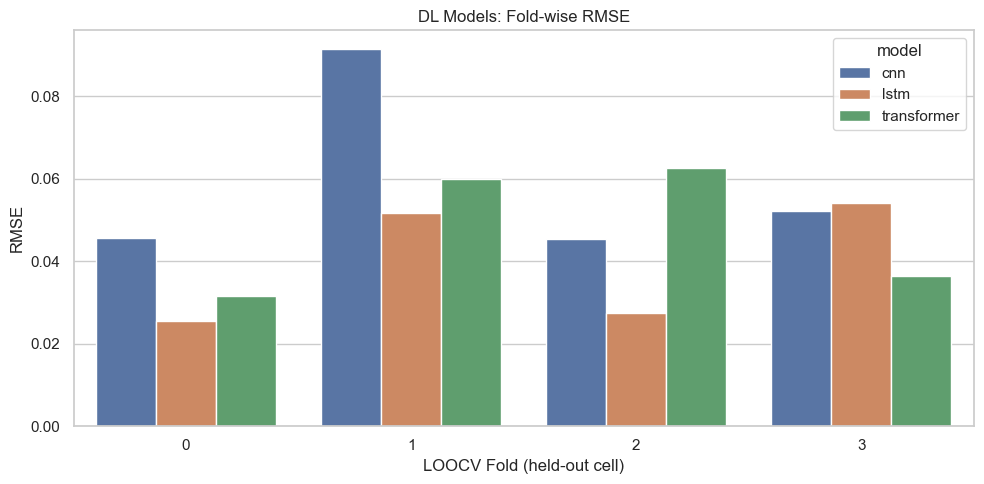

In [4]:
dl_runs = runs_df[runs_df["model"].isin(dl_models)].copy()
fold_rmse = dl_runs.groupby(["model", "fold"])["rmse"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=fold_rmse, x="fold", y="rmse", hue="model", ax=ax)
ax.set_xlabel("LOOCV Fold (held-out cell)")
ax.set_ylabel("RMSE")
ax.set_title("DL Models: Fold-wise RMSE")
plt.tight_layout()
plt.show()

## 4. Seed Variance Analysis

Seed variance across runs:
      model  fold  rmse_mean  rmse_std  n_seeds
        cnn     0   0.045598  0.016103        3
        cnn     1   0.091416  0.099286        3
        cnn     2   0.045389  0.012415        3
        cnn     3   0.052268  0.008923        3
       lstm     0   0.025609  0.006567        3
       lstm     1   0.051680  0.017873        3
       lstm     2   0.027462  0.016637        3
       lstm     3   0.054086  0.016110        3
transformer     0   0.031600  0.005142        3
transformer     1   0.060020  0.025531        3
transformer     2   0.062644  0.058785        3
transformer     3   0.036486  0.011880        3


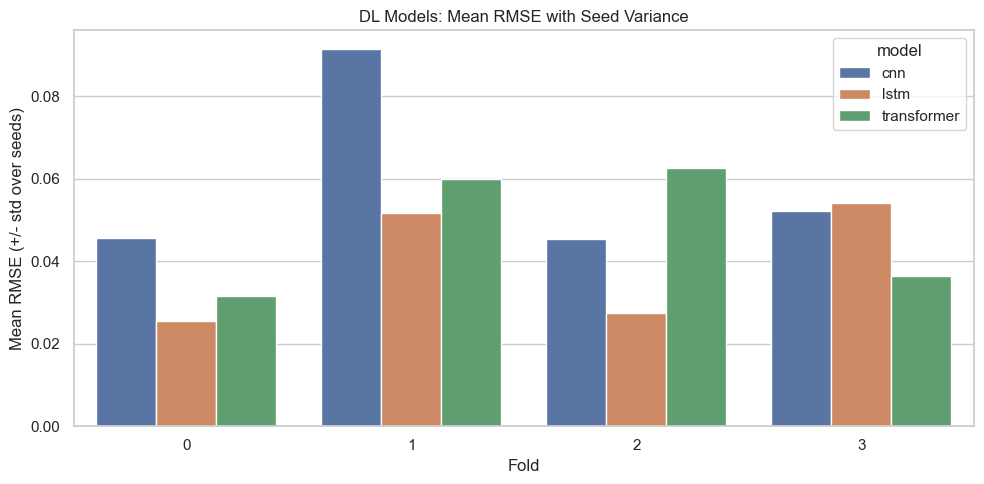

In [5]:
seed_stats = dl_runs.groupby(["model", "fold"]).agg(
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Seed variance across runs:")
print(seed_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=seed_stats, x="fold", y="rmse_mean", hue="model", ax=ax)
ax.set_xlabel("Fold")
ax.set_ylabel("Mean RMSE (+/- std over seeds)")
ax.set_title("DL Models: Mean RMSE with Seed Variance")
plt.tight_layout()
plt.show()

## 5. DL vs Classical Comparison

      Model  Category     RMSE  RMSE_std      MAE    MaxAE        R2   R2_std
        SVR Classical 0.025303  0.019143 0.022114 0.051437  0.901034 0.113415
        GPR Classical 0.028286  0.016620 0.026185 0.055816  0.885796 0.097213
         RF Classical 0.029348  0.018821 0.023909 0.082495  0.878977 0.126347
       LSTM        DL 0.039709  0.013218 0.034211 0.086210  0.629946 0.236428
TRANSFORMER        DL 0.047688  0.013785 0.041543 0.092338  0.356188 0.514923
        CNN        DL 0.058668  0.019108 0.047501 0.132277  0.069596 0.752865
      NAIVE Classical 0.107574  0.024956 0.090421 0.209816 -0.413220 0.368720


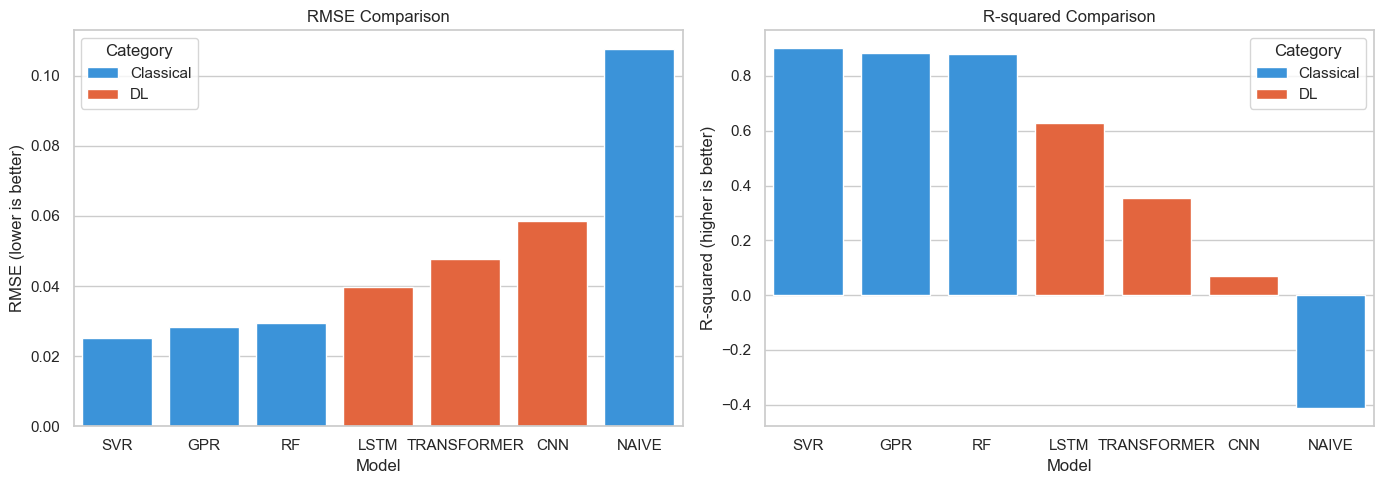

In [6]:
summary_rows = []
for name, m in all_results.items():
    if not isinstance(m, dict) or "rmse_mean" not in m:
        continue
    category = "DL" if name in dl_models else "Classical"
    summary_rows.append({
        "Model": name.upper(),
        "Category": category,
        "RMSE": m["rmse_mean"],
        "RMSE_std": m["rmse_std"],
        "MAE": m["mae_mean"],
        "MaxAE": m["maxae_mean"],
        "R2": m["r2_mean"],
        "R2_std": m["r2_std"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("RMSE")
print(summary_df.to_string(index=False, float_format="%.6f"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"Classical": "#2196F3", "DL": "#FF5722"}
sns.barplot(data=summary_df, x="Model", y="RMSE", hue="Category", palette=palette, ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE (lower is better)")
sns.barplot(data=summary_df, x="Model", y="R2", hue="Category", palette=palette, ax=axes[1])
axes[1].set_title("R-squared Comparison")
axes[1].set_ylabel("R-squared (higher is better)")
plt.tight_layout()
plt.show()

## 6. Training Convergence Analysis

In [7]:
ckpt_dir = Path("experiments/models/nasa")
ckpt_files = sorted(ckpt_dir.glob("*.pt")) if ckpt_dir.exists() else []
print(f"Found {len(ckpt_files)} DL checkpoints in {ckpt_dir}")
for f in ckpt_files[:10]:
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")


Found 36 DL checkpoints in experiments/models/nasa
  cnn_fold0_seed42.pt (156.0 KB)
  cnn_fold0_seed43.pt (763.8 KB)
  cnn_fold0_seed44.pt (763.8 KB)
  cnn_fold1_seed42.pt (156.0 KB)
  cnn_fold1_seed43.pt (264.1 KB)
  cnn_fold1_seed44.pt (171.8 KB)
  cnn_fold2_seed42.pt (203.2 KB)
  cnn_fold2_seed43.pt (338.3 KB)
  cnn_fold2_seed44.pt (107.8 KB)
  cnn_fold3_seed42.pt (205.0 KB)


## 7. Inference Time Comparison

      Model  Inference Time (ms)
      NAIVE             0.000641
        SVR             0.041396
        GPR             0.098800
        CNN             0.785803
       LSTM             0.940553
TRANSFORMER             4.580859
         RF            19.795250


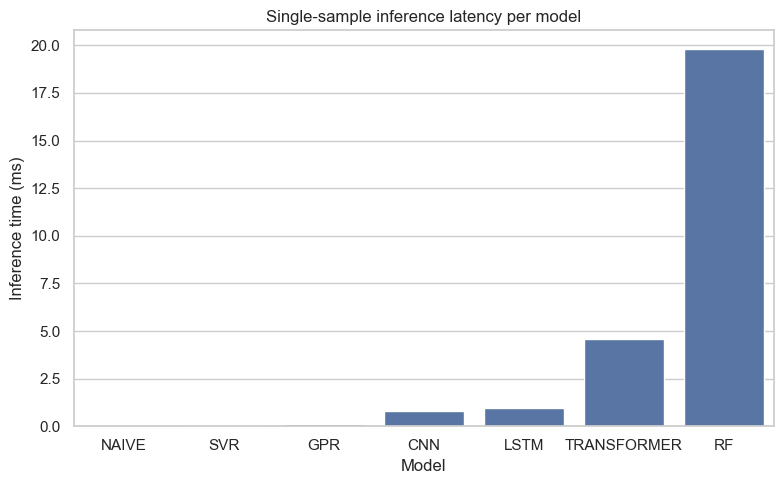

In [8]:
time_rows = []
for name, m in all_results.items():
    if not isinstance(m, dict) or "rmse_mean" not in m:
        continue
    time_rows.append({
        "Model": name.upper(),
        "Inference Time (ms)": m.get("inference_time_ms_mean", np.nan),
    })

time_df = pd.DataFrame(time_rows).sort_values("Inference Time (ms)")
print(time_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=time_df, x="Model", y="Inference Time (ms)", ax=ax)
ax.set_title("Single-sample inference latency per model")
ax.set_ylabel("Inference time (ms)")
plt.tight_layout()
plt.show()


## 8. Summary

**Key findings (NASA PCoE, leakage-free protocol):**
- Classical models still lead: SVR RMSE ≈ 0.025 (R² ≈ 0.90) vs best DL (LSTM ≈ 0.040, R² ≈ 0.63)
- With only 636 samples and 4 cells, DL models trail but are functional (no negative mean R²)
- Seed variability remains highest for CNN/Transformer — DL is data-limited here
- Sequence-based approaches need more data to generalize (see CALCE results in notebook 06)
